# Music and Mental Health

Exploratory data cleaning and visualisation of a self-reported music and mental health survey.

## Overview

This notebook profiles the supplied survey data, applies a small set of documented cleaning rules, and examines music preferences alongside self-reported wellbeing measures. The analysis is descriptive only; it does not support clinical or causal conclusions.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_color_codes()
sns.set_palette('magma', n_colors=8)
sns.set_theme(style='whitegrid', palette='magma')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 180

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / 'data' / 'Impact_music_mental_health.csv'
IMAGE_DIR = PROJECT_ROOT / 'images'

## Load and profile the data

In [2]:
raw = pd.read_csv(DATA_PATH)

profile = pd.DataFrame({
    'rows': [raw.shape[0]],
    'columns': [raw.shape[1]],
    'exact_duplicate_rows': [raw.duplicated().sum()],
    'missing_cells': [int(raw.isna().sum().sum())],
})
display(profile)

print(f'Dataset shape: {raw.shape}')
raw.info()
display(raw.describe().T)
display(raw.describe(exclude='number').T)

missing_before = raw.isna().sum().loc[lambda series: series.gt(0)].sort_values(ascending=False)
display(missing_before.to_frame('missing_values'))
raw.head(3)

,rows,columns,exact_duplicate_rows,missing_cells
0,736,33,0,129


Dataset shape: (736, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    object 
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    object 
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    object 
 5   Instrumentalist               732 non-null    object 
 6   Composer                      735 non-null    object 
 7   Fav genre                     736 non-null    object 
 8   Exploratory                   736 non-null    object 
 9   Foreign languages             732 non-null    object 
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    object 
 12  Frequency [Country]           736 non-n

,count,mean,std,min,25%,50%,75%,max
Age,735.0,2.520680e+01,1.205497e+01,10.0,18.0,21.0,28.0,89.0
Hours per day,736.0,3.572758e+00,3.028199e+00,0.0,2.0,3.0,5.0,24.0
BPM,629.0,1.589948e+06,3.987261e+07,0.0,100.0,120.0,144.0,999999999.0
Anxiety,736.0,5.837636e+00,2.793054e+00,0.0,4.0,6.0,8.0,10.0
Depression,736.0,4.796196e+00,3.028870e+00,0.0,2.0,5.0,7.0,10.0
Insomnia,736.0,3.738451e+00,3.088689e+00,0.0,1.0,3.0,6.0,10.0
OCD,736.0,2.637228e+00,2.842017e+00,0.0,0.0,2.0,5.0,10.0


,count,unique,top,freq
Timestamp,736,729,09/01/2022 15:24,2
Primary streaming service,735,6,Spotify,458
While working,733,2,Yes,579
Instrumentalist,732,2,No,497
Composer,735,2,No,609
Fav genre,736,16,Rock,188
Exploratory,736,2,Yes,525
Foreign languages,732,2,Yes,404
Frequency [Classical],736,4,Rarely,259
Frequency [Country],736,4,Never,343


,missing_values
BPM,107
Music effects,8
Instrumentalist,4
Foreign languages,4
While working,3
Age,1
Primary streaming service,1
Composer,1


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.


## Cleaning choices

- Remove responses with `Age > 70`, `Hours per day >= 15`, or `BPM > 200`.
- Remove timestamp and permission fields because they are not used in the visual analysis.
- Fill the remaining age value with the mean; fill selected categorical fields with their mode.
- Fill missing BPM values using the mean within each favourite-genre group, then the overall median for any remaining gaps.

In [3]:
data = raw.copy()
rows_before = len(data)

age_outliers = data['Age'].gt(70)
hours_outliers = data['Hours per day'].ge(15)
bpm_outliers = data['BPM'].gt(200)
excluded = age_outliers | hours_outliers | bpm_outliers

cleaning_summary = pd.DataFrame({
    'rule': ['Age > 70', 'Hours per day >= 15', 'BPM > 200', 'Excluded by any rule'],
    'rows_flagged': [age_outliers.sum(), hours_outliers.sum(), bpm_outliers.sum(), excluded.sum()],
})
display(cleaning_summary)

data = data.loc[~excluded].copy()
data.drop(columns=['Timestamp', 'Permissions'], inplace=True)

data['Age'] = data['Age'].fillna(data['Age'].mean()).round(0)
categorical_columns = [
    'Primary streaming service', 'While working', 'Instrumentalist',
    'Composer', 'Foreign languages', 'Music effects',
]
for column in categorical_columns:
    data[column] = data[column].fillna(data[column].mode().iat[0])

genre_mean_bpm = data.groupby('Fav genre')['BPM'].transform('mean')
data['BPM'] = data['BPM'].fillna(genre_mean_bpm)
data['BPM'] = data['BPM'].fillna(data['BPM'].median())

quality_after = pd.DataFrame({
    'rows_before_cleaning': [rows_before],
    'rows_after_cleaning': [len(data)],
    'columns_after_cleaning': [data.shape[1]],
    'missing_cells_after_cleaning': [int(data.isna().sum().sum())],
    'exact_duplicate_rows_after_cleaning': [int(data.duplicated().sum())],
})
display(quality_after)

df = data.copy()
print(f'Analysis copy shape: {df.shape}')

,rule,rows_flagged
0,Age > 70,6
1,Hours per day >= 15,8
2,BPM > 200,9
3,Excluded by any rule,22


,rows_before_cleaning,rows_after_cleaning,columns_after_cleaning,missing_cells_after_cleaning,exact_duplicate_rows_after_cleaning
0,736,714,31,0,0


Analysis copy shape: (714, 31)


## Age distribution

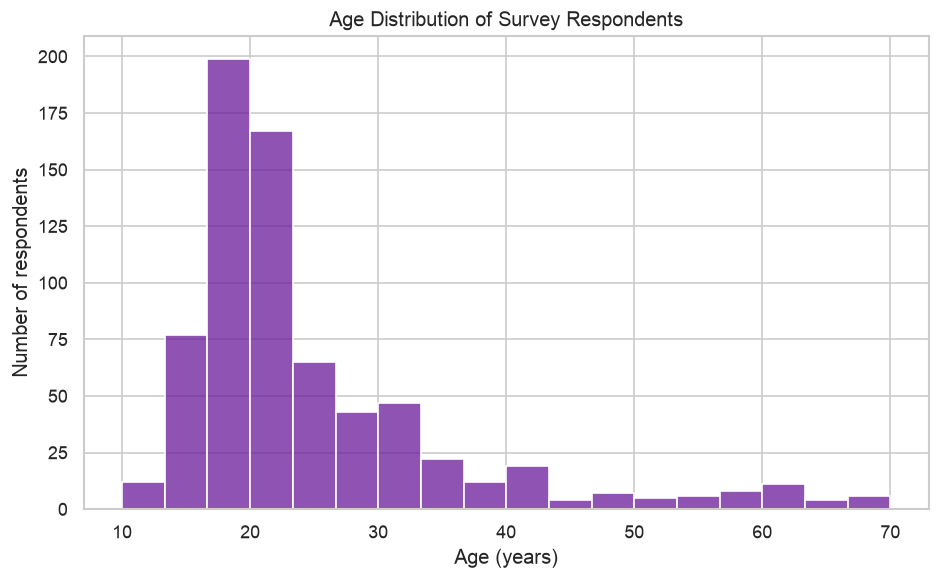

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=data, x='Age', bins=18, color='#6a1b9a', edgecolor='white', ax=ax)
ax.set_title('Age Distribution of Survey Respondents')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of respondents')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'age_distribution.png', bbox_inches='tight')
plt.show()

## EDM listening frequency

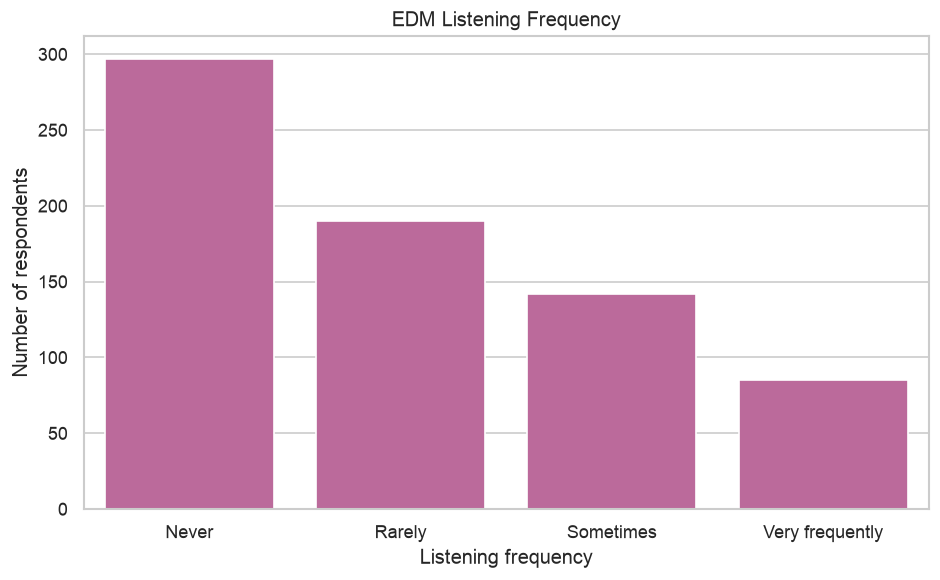

In [5]:
frequency_order = ['Never', 'Rarely', 'Sometimes', 'Very frequently']
edm_counts = data['Frequency [EDM]'].value_counts().reindex(frequency_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=edm_counts.index, y=edm_counts.values, color='#c85d9e', ax=ax)
ax.set_title('EDM Listening Frequency')
ax.set_xlabel('Listening frequency')
ax.set_ylabel('Number of respondents')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'edm_listening_frequency.png', bbox_inches='tight')
plt.show()

## Correlation among numeric variables

,correlation_with_age
Anxiety,-0.147065
OCD,-0.122856
Hours per day,-0.098356
Depression,-0.087594
BPM,-0.019707
Insomnia,0.039343
Age,1.000000


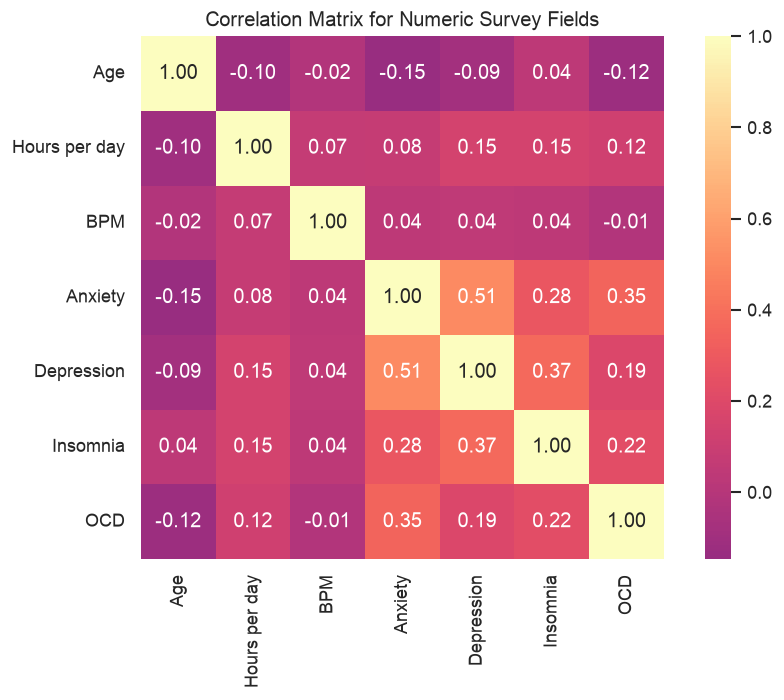

In [6]:
numeric_columns = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
correlation = data[numeric_columns].corr(numeric_only=True)
display(correlation['Age'].sort_values().to_frame('correlation_with_age'))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, cmap='magma', center=0, annot=True, fmt='.2f', square=True, ax=ax)
ax.set_title('Correlation Matrix for Numeric Survey Fields')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Favourite genre and age

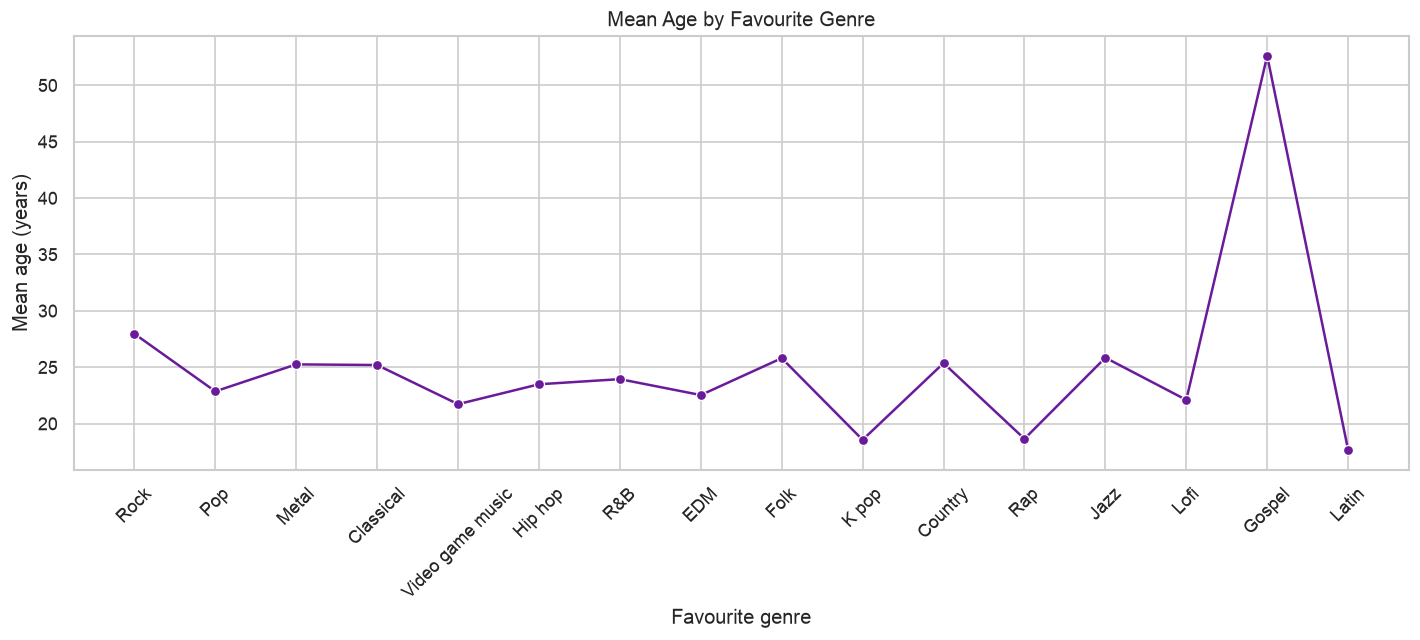

In [7]:
genre_order = data['Fav genre'].value_counts().index
genre_age = data.groupby('Fav genre', observed=True)['Age'].mean().reindex(genre_order)

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.lineplot(x=genre_age.index, y=genre_age.values, marker='o', errorbar=None, color='#6a1b9a', ax=ax)
ax.set_title('Mean Age by Favourite Genre')
ax.set_xlabel('Favourite genre')
ax.set_ylabel('Mean age (years)')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'age_by_favourite_genre.png', bbox_inches='tight')
plt.show()

## Favourite genre and listening time

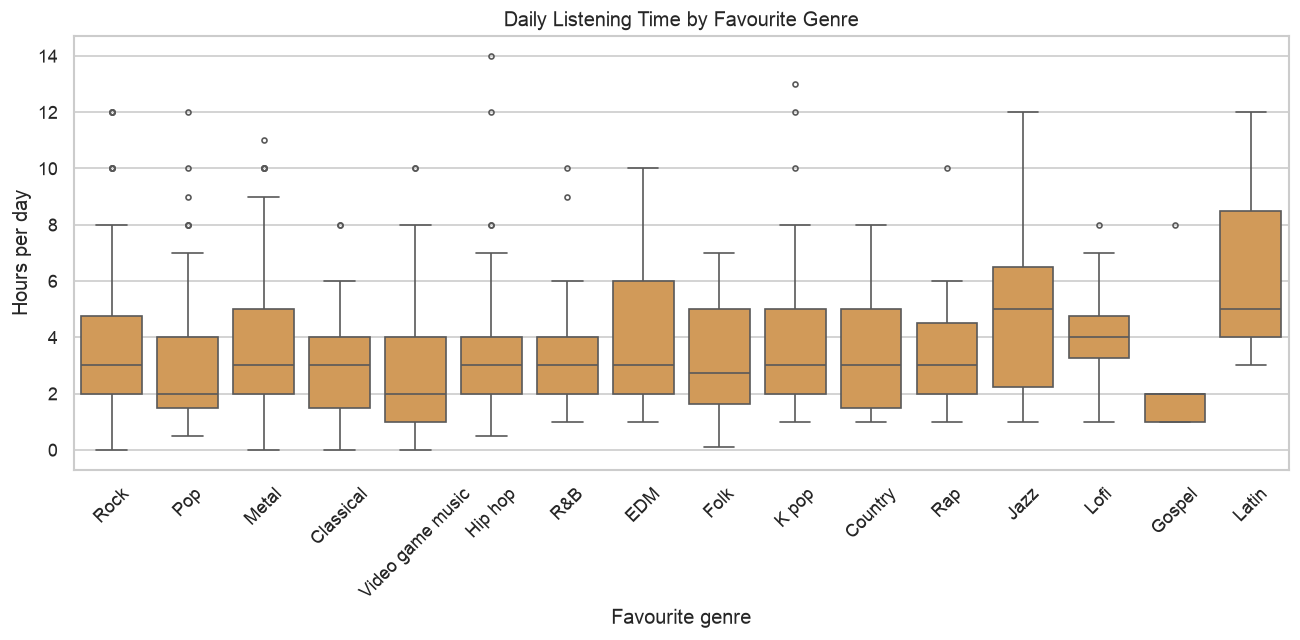

In [8]:
genre_order = data['Fav genre'].value_counts().index

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=data, x='Fav genre', y='Hours per day', order=genre_order, color='#e59c45', fliersize=3, ax=ax)
ax.set_title('Daily Listening Time by Favourite Genre')
ax.set_xlabel('Favourite genre')
ax.set_ylabel('Hours per day')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'listening_time_by_genre.png', bbox_inches='tight')
plt.show()

## Self-reported anxiety by favourite genre

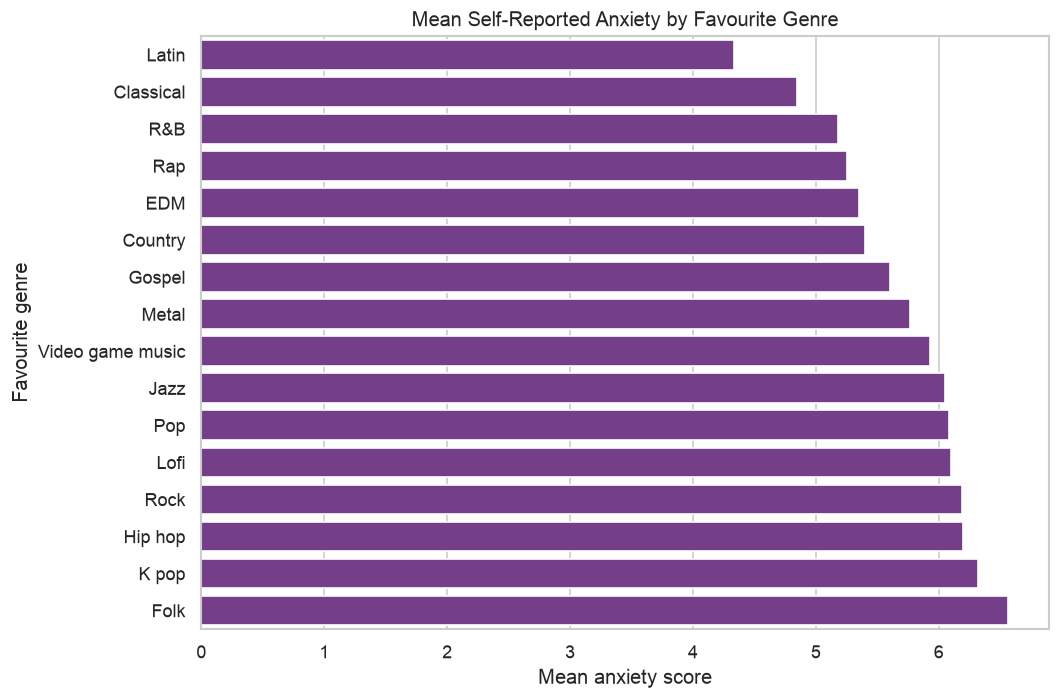

,mean_anxiety
Fav genre,
Latin,4.33
Classical,4.85
R&B,5.18
Rap,5.25
EDM,5.35
Country,5.40
Gospel,5.60
Metal,5.76
Video game music,5.93


In [9]:
genre_anxiety = data.groupby('Fav genre', observed=True)['Anxiety'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=genre_anxiety.values, y=genre_anxiety.index, color='#7b3294', ax=ax)
ax.set_title('Mean Self-Reported Anxiety by Favourite Genre')
ax.set_xlabel('Mean anxiety score')
ax.set_ylabel('Favourite genre')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'anxiety_by_genre.png', bbox_inches='tight')
plt.show()

genre_anxiety.to_frame('mean_anxiety').round(2)

## Age by reported music effect

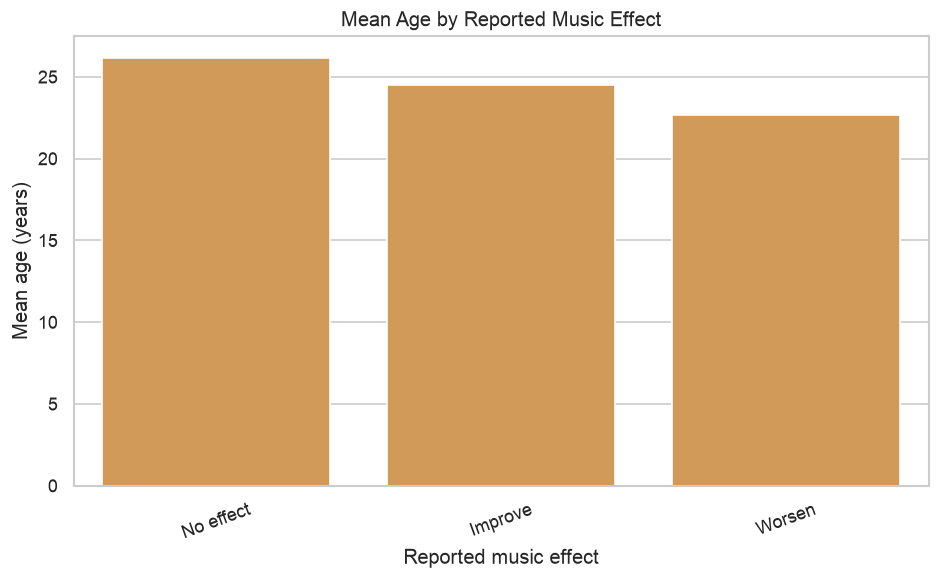

In [10]:
age_effect = data.groupby('Music effects', observed=True)['Age'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=age_effect.index, y=age_effect.values, color='#e59c45', ax=ax)
ax.set_title('Mean Age by Reported Music Effect')
ax.set_xlabel('Reported music effect')
ax.set_ylabel('Mean age (years)')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'age_by_music_effect.png', bbox_inches='tight')
plt.show()

## Age by favourite genre and reported music effect

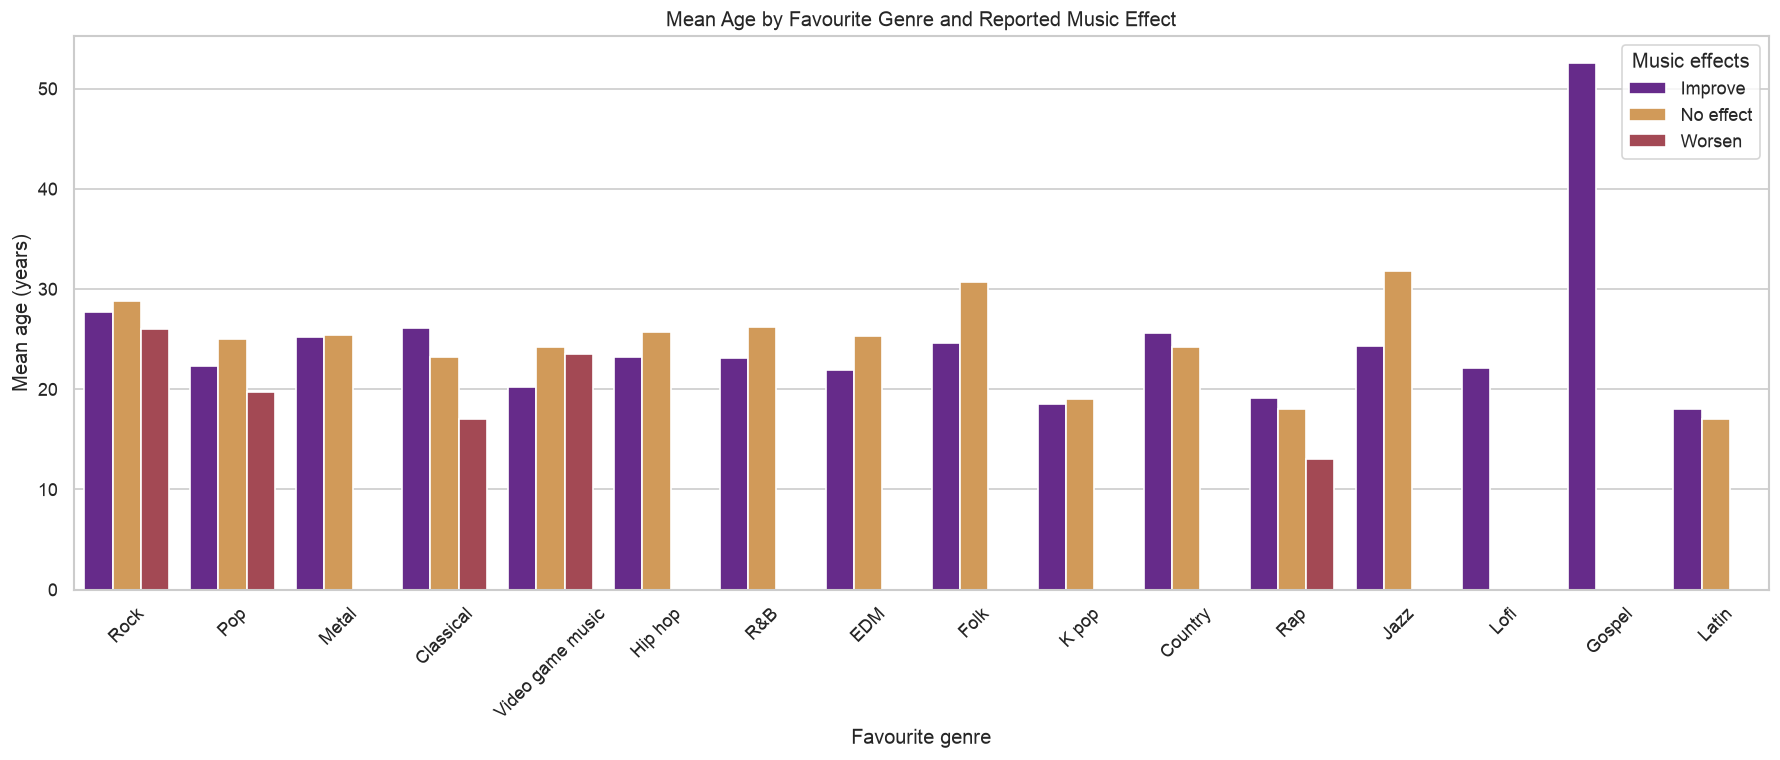

In [11]:
fig, ax = plt.subplots(figsize=(15, 6.5))
sns.barplot(
    data=data, x='Fav genre', y='Age', hue='Music effects',
    order=genre_order, errorbar=None,
    palette={'Improve': '#6a1b9a', 'No effect': '#e59c45', 'Worsen': '#b23a48'},
    ax=ax,
)
ax.set_title('Mean Age by Favourite Genre and Reported Music Effect')
ax.set_xlabel('Favourite genre')
ax.set_ylabel('Mean age (years)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Music effects')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'age_by_genre_and_music_effect.png', bbox_inches='tight')
plt.show()

## Notes

The survey is self-reported and cross-sectional. The charts describe this sample only; differences between groups should not be interpreted as evidence that music preferences cause changes in mental health.